# Methoden en Technieken -- Blok 2

## Datapunt 2b,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld machine learning, deep learning, kennisrepresentatie, computer vision** en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 

https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter17_image-generation.ipynb

base model


## De opdracht

De volgende code laadt de data in. Dit is een gedeeltelijk gelabelde variant van de MNIST dataset

In [70]:
#| include: false

# Standard library
import os
import pickle

# Environment configuration
os.environ["KERAS_BACKEND"] = "torch"

# Core numerical and ML libraries
import numpy as np
import torch
import keras
from keras import layers, Model, Input, optimizers

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import visualkeras

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


# Hardware check
if torch.cuda.is_available():
    print('Notebook gebruikt windows GPU')
elif torch.mps.is_available():
    print('Notebook gebruikt apple GPU')
else:
    print('Notebook gebruikt CPU')


# Data loading
with open('data_2b_new.pkl', 'rb') as file:
    x_labeled, y_labeled, x_unlabeled = pickle.load(file)


Notebook gebruikt windows GPU


### Helper functions for iterations (save, load, plot)

In [ ]:
def _resolve_history_dict(history_or_dict):
    if history_or_dict is None:
        raise ValueError("history_or_dict is None.")
    # Keras History object
    hist = getattr(history_or_dict, 'history', None)
    if isinstance(hist, dict):
        return hist
    # Already a dict-like
    if isinstance(history_or_dict, dict):
        return history_or_dict
    raise TypeError("Expected a Keras History or dict of lists.")


def plot_training_curves(history, title_prefix=None):
    """Plot train/val curves for common metrics.

    Supports: loss, accuracy (various), and extra pairs like reconstruction_loss/kl_loss if present.
    """
    h = _resolve_history_dict(history)
    keys = set(h.keys())

    # Primary pairs
    pairs = []
    if 'loss' in keys or 'val_loss' in keys:
        pairs.append(('loss', 'val_loss'))

    # Accuracy candidates
    acc_candidates = ['accuracy', 'sparse_categorical_accuracy', 'categorical_accuracy', 'binary_accuracy']
    acc_key = next((k for k in acc_candidates if k in keys), None)
    if acc_key:
        pairs.append((acc_key, f'val_{acc_key}'))

    # Extra VAE metrics if present
    for base in ['reconstruction_loss', 'kl_loss']:
        train_k = base
        val_k = f'val_{base}'
        if train_k in keys or val_k in keys:
            pairs.append((train_k, val_k))

    if not pairs:
        # Fallback: plot any available series
        for k in sorted(keys):
            vk = f'val_{k}'
            pairs.append((k, vk))

    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    if n == 1:
        axes = [axes]

    # Determine epochs from first available series length
    ref_series = next((h[p[0]] for p in pairs if p[0] in h and isinstance(h[p[0]], (list, tuple)) and len(h[p[0]])>0), None)
    if ref_series is None:
        ref_series = next((h[p[1]] for p in pairs if p[1] in h and isinstance(h[p[1]], (list, tuple)) and len(h[p[1]])>0), None)
    num_epochs = len(ref_series) if ref_series is not None else None
    epochs = range(1, (num_epochs or 0) + 1)

    for ax, (train_k, val_k) in zip(axes, pairs):
        plotted = False
        if train_k in h and isinstance(h[train_k], (list, tuple)):
            ax.plot(epochs, h[train_k], label=f"Train {train_k}")
            plotted = True
        if val_k in h and isinstance(h[val_k], (list, tuple)):
            ax.plot(epochs, h[val_k], label=f"Val {train_k}")
            plotted = True
        ax.set_title(f"{title_prefix+' - ' if title_prefix else ''}{train_k}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(train_k)
        ax.grid(True, alpha=0.3)
        if plotted:
            ax.legend()
        else:
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()


def save_model_and_history(model, history, name='model', models_dir='models'):
    """Save model weights and training history to disk.
    
    Args:
        model: Keras model to save
        history: Training history (Keras History object or dict)
        name: Base name for saved files (no extension needed)
        models_dir: Directory to save in (default: 'models')
    
    Returns:
        Dict with 'weights' and 'history' paths
    """
    os.makedirs(models_dir, exist_ok=True)
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    hist_path = os.path.join(models_dir, f"{name}_hist.pkl")

    # Save weights
    model.save_weights(weights_path)

    # Save history dict
    h = _resolve_history_dict(history)
    with open(hist_path, 'wb') as f:
        pickle.dump(h, f)

    print(f"Saved weights → {weights_path}")
    print(f"Saved history → {hist_path}")
    return {"weights": weights_path, "history": hist_path}


def load_vae_weights(vae, name, models_dir='models'):
    """Load VAE weights if file exists.
    
    Args:
        vae: VAE model to load weights into
        name: Base name of saved file (no extension needed)
        models_dir: Directory to load from (default: 'models')
    
    Returns:
        True if loaded successfully, False otherwise
    """
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    if not os.path.exists(weights_path):
        print(f"Warning: VAE weights not found at {weights_path}")
        return False
    vae.load_weights(weights_path)
    print(f"Loaded VAE weights from: {weights_path}")
    return True

In [62]:
print(f"Observations — labeled: {x_labeled.shape[0]}, unlabeled: {x_unlabeled.shape[0]}")

Observations — labeled: 250, unlabeled: 69750


## Split strategy

De data is 250 gelabelde voorbeelden van de MNIST data set en 69750 ongelabelde voorbeelde van de dataset. Volgens de opdracht gever is de data set een split van de orginele MNIST. Omdat ik al voor kennis heb van de dataset en de orginele data al goed gebalanceerd is kies ik er voor om een normale split zonder stratify te doen.

In [72]:
# Train/Val/Test split for labeled data (no test labels kept in memory)
RANDOM_SEED = 42

# First split: hold out test set (20%)
x_trainval, x_test, y_trainval, y_test_true = train_test_split(
    x_labeled, y_labeled, test_size=0.20, random_state=RANDOM_SEED, stratify=y_labeled
)

# Second split: from remaining, create validation set (20% of trainval → 16% of total)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.20, random_state=RANDOM_SEED, stratify=y_labeled
)

# Print shapes for visibility
print("Split complete:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_test (held out):", x_test.shape)

# Safety: remove test references to avoid accidental use

del x_test, y_test_true


Split complete:
x_train: (160, 28, 28, 1) y_train: (160,)
x_val: (40, 28, 28, 1) y_val: (40,)
x_test (held out): (50, 28, 28, 1)


De opdracht is om een *semi-supervised* model te trainen dat deze data zo goed mogelijk (rekening houdend met tijd en beschikbare hardware) kan classificeren. De enige voorwaarde is dat dit model gebruik moet maken van een *variational auto encoder* die unsupervised getrained is op deze data. Zie onder andere lessen 11, 12 en 13 van M&T blok 2 voor inspiratie.

Je zult waarschijnlijk meerdere iteraties op beide het *unsupervised* (de VAE) gedeelte en het *supervised* gedeelte van je model doorlopen. Zorg dat deze iteraties duidelijk in je notebook beschreven staan, wis ze niet!

### Deel 1

Voer een data preparatie/verkenning uit, leg kort uit wat je opvalt. Stel op basis hiervan een korte lijst van *requirements* op waar je model aan moet voldoen.

x_train: (160, 28, 28, 1) uint8
y_train: (160,) uint8
x_unlabeled: (69750, 28, 28, 1) float32
x_train pixels -> min: 0.000, max: 1.000, mean: 0.133, std: 0.311
x_unlabeled pixels -> min: 0.000, max: 1.000, mean: 0.131, std: 0.308
Train labels gevonden: [0 1 2 3 4 5 6 7 8 9]
Train per-klasse aantallen: {np.uint8(0): np.int64(20), np.uint8(1): np.int64(17), np.uint8(2): np.int64(12), np.uint8(3): np.int64(14), np.uint8(4): np.int64(12), np.uint8(5): np.int64(19), np.uint8(6): np.int64(16), np.uint8(7): np.int64(17), np.uint8(8): np.int64(13), np.uint8(9): np.int64(20)}


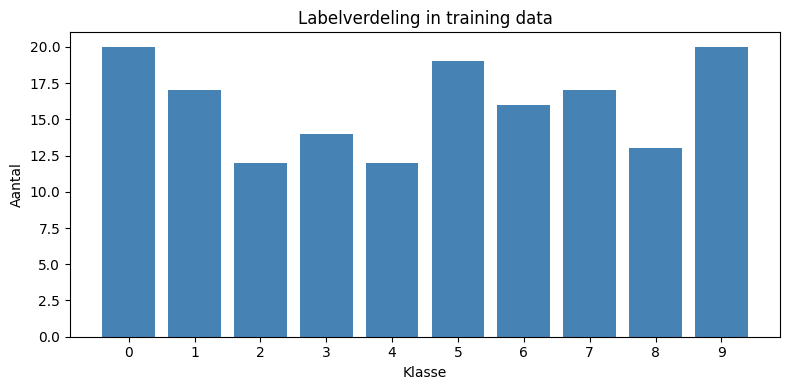

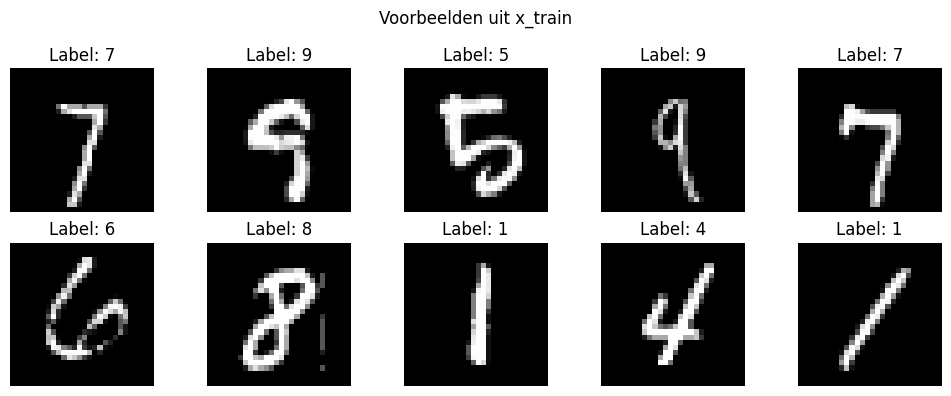

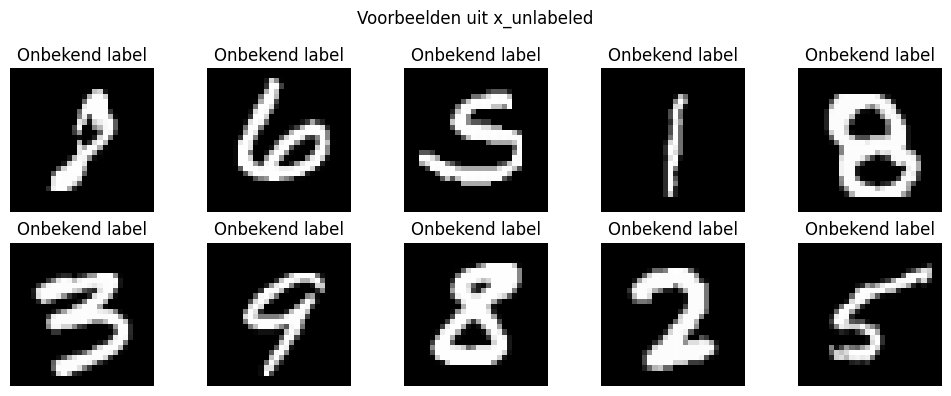

In [74]:
# Data-exploratie voor Datapunt 2b (MNIST variant, deels gelabeld)
# Basisinformatie (alleen TRAIN + unlabeled; geen VAL/TEST)
print("x_train:", x_train.shape, y_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_unlabeled:", x_unlabeled.shape, x_unlabeled.dtype)

# Stats helper

def describe_pixels(name, arr):
    arr_min = float(np.min(arr))
    arr_max = float(np.max(arr))
    arr_mean = float(np.mean(arr))
    arr_std = float(np.std(arr))
    print(f"{name} pixels -> min: {arr_min:.3f}, max: {arr_max:.3f}, mean: {arr_mean:.3f}, std: {arr_std:.3f}")

# Alleen TRAIN en UNLABELED verkennen (geen VAL/TEST)
describe_pixels("x_train", x_train)
describe_pixels("x_unlabeled", x_unlabeled)

# Labelverdeling (alleen TRAIN)
unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Train labels gevonden:", unique_labels)
print("Train per-klasse aantallen:", dict(zip(unique_labels, label_counts)))

plt.figure(figsize=(8,4))
plt.bar(unique_labels, label_counts, color="steelblue")
plt.title("Labelverdeling in training data")
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(unique_labels)
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (TRAIN)
n_show = 10
rng = np.random.default_rng(42)
idx_l = rng.choice(len(x_train), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_l):
    img = x_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_train")
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (ONGELABELD)
idx_u = rng.choice(len(x_unlabeled), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_u):
    img = x_unlabeled[i]
    ax.imshow(img, cmap="gray")
    ax.set_title("Onbekend label")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_unlabeled")
plt.tight_layout()
plt.show()

> Jouw antwoorden hier, voeg gerust cellen toe

## Baseline model - OLD

Het baseline model is de versie uit keras/cholet/docent notebook met een classification head toegevoegd na het trainen van de VAE om een minimale setup te maken vom performance mee te meten. Voor dfe evaluatie zal ik het mode als een geheel beschouwen voor het itereren omdat het doel is een zo goed mogelijk model te maken met zo min mogelijke complexity.

In [83]:
# baseline_inputs = Input(shape=(28, 28, 1), name="baseline_input")
# x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(baseline_inputs)
# x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
# x = layers.Flatten()(x)
# x = layers.Dense(16, activation="relu", name="pre_z_dense")(x)  # same layer as in VAE encoder
# baseline_outputs = layers.Dense(10, activation="softmax", name="baseline_logits")(x)
# baseline_model = Model(baseline_inputs, baseline_outputs, name="baseline_cnn_classifier")

# baseline_model.compile(optimizer=optimizers.Adam(),
#                        loss="sparse_categorical_crossentropy",
#                        metrics=["accuracy"]) 

# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss", patience=12, restore_best_weights=True, min_delta=1e-4, verbose=1
# )

# baseline_hist = baseline_model.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     epochs=200,
#     batch_size=128,
#     callbacks=[early_stop],
#     verbose=1
# )

### Deel 2

Maak een eerste model en verbeter dit via een iteratief en systematisch proces.

## Sampler & VAE architecture

In [84]:
class Sampler(keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator()
        self.built = True

    def call(self, z_mean, z_log_var):
        batch_size = keras.ops.shape(z_mean)[0]
        z_size = keras.ops.shape(z_mean)[1]
        epsilon = keras.random.normal((batch_size, z_size), seed=self.seed_generator)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        return self.encoder(inputs)

    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        z_mean, z_log_var = y_pred
        z = self.sampler(z_mean, z_log_var)
        reconstruction = self.decoder(z)

        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(keras.ops.binary_crossentropy(x, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
        total_loss = reconstruction_loss + keras.ops.mean(kl_loss)

        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return total_loss

## Base model 

### VAE

In [ ]:
latent_dim = 2

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


In [33]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/100


491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - kl_loss: 2.0328 - loss: 187.3901 - reconstruction_loss: 185.3013 - val_kl_loss: 3.1575 - val_loss: 135.2760 - val_reconstruction_loss: 132.0889
Epoch 2/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - kl_loss: 3.2032 - loss: 126.7242 - reconstruction_loss: 123.5130 - val_kl_loss: 3.3187 - val_loss: 120.2136 - val_reconstruction_loss: 116.8643
Epoch 3/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - kl_loss: 3.3128 - loss: 116.1205 - reconstruction_loss: 112.7979 - val_kl_loss: 3.2868 - val_loss: 113.7346 - val_reconstruction_loss: 110.4201
Epoch 4/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - kl_loss: 3.3328 - loss: 111.5835 - reconstruction_loss: 108.2558 - val_kl_loss: 3.2939 - val_loss: 110.3869 - val_reconstruction_loss: 107.0641
Epoch 5/100
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - kl_loss: 3.3217 - loss: 108.9939 - reconstruction_loss: 105.6777 - val_kl_loss: 3.3371 - val_loss: 107.9568 - val_reconstruction_loss: 104.5874
Epoch 6

### Save base model VAE

In [ ]:
# Save base VAE model and history using reusable function
paths = save_model_and_history(vae, hist, name='base_model')

### Base model (Classifier)

In [ ]:
# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features

# Load top-trained VAE weights if available via reusable function
loaded = load_vae_weights(vae, name='base_model')
if not loaded:
    print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Loaded VAE weights from: models/model_it1.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1312 - loss: 2.4371 - val_accuracy: 0.1500 - val_loss: 2.4306
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1312 - loss: 2.4268 - val_accuracy: 0.1500 - val_loss: 2.4224
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1375 - loss: 2.4166 - val_accuracy: 0.1750 - val_loss: 2.4146
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1437 - loss: 2.4072 - val_accuracy: 0.2000 - val_loss: 2.4067
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1500 - loss: 2.3976 - val_accuracy: 0.2000 - val_loss: 2.3986
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1562 - loss: 2.3881 - val_accuracy: 0.2000 - val_loss: 2.3905
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1562 - loss: 2.3787 - val_accuracy: 0.2250 - val_loss: 2.3826
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accur

In [85]:
# encoder.summary()

# for layer in encoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(encoder, scale_z=0.03, legend=True)

# decoder.summary()

# for layer in decoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(decoder, scale_z = 0.03, legend=True)

# vae.summary()

## Evaluate base model

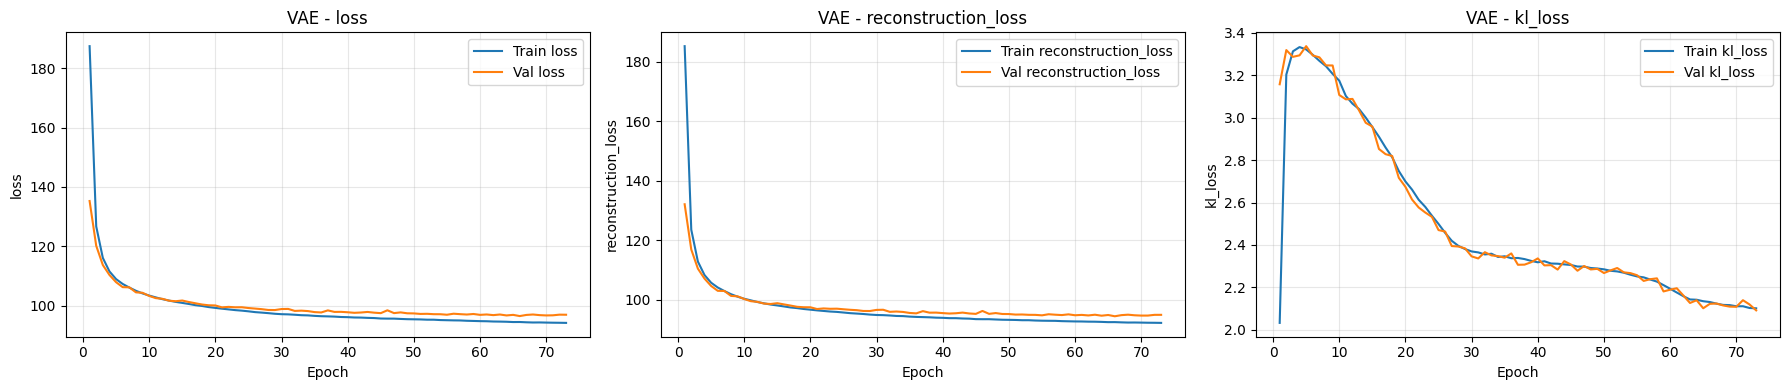

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


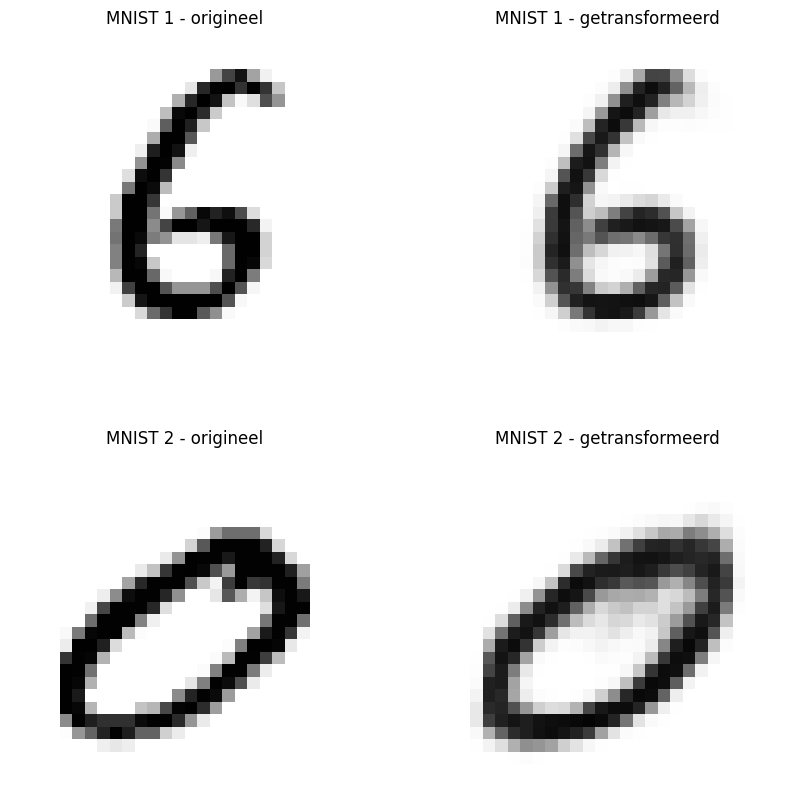

In [88]:
plot_training_curves(hist, title_prefix='VAE')

# Preview reconstruction using UNLABELED validation slice (no labeled data involved)
latent, _ = vae.encoder.predict(x_train)
xnew = vae.decoder.predict(latent)

plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
plt.imshow(1-x_train[1].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - origineel')
plt.subplot(2,2,2)
plt.imshow(1-xnew[1,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - getransformeerd')
plt.subplot(2,2,3)
plt.imshow(1-x_train[2].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - origineel')
plt.subplot(2,2,4)
plt.imshow(1-xnew[2,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - getransformeerd')
plt.show()

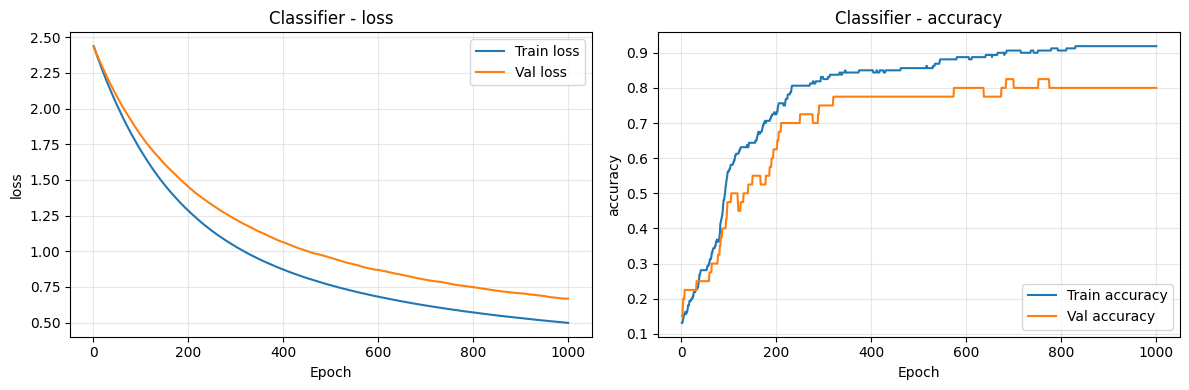

In [89]:
# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

## Iteratie 1

Na de evaluatie van het base model valt op dat de encoder en de decoder correct werken. Maar vervolgens lukt het de classifier niet om veel performance te verkrijgen met de kleine dataset, de latent representaties zorgen er dus niet voor dat de classifier beter instaat is de cijfers uit elkaar te halen. Om de classifier meer geven om mee te werken ga ik het aantal latent dimension verhogen. Een latente dimensie van 2 is onvoldoende voor de complexiteit van de data om alle nuttige features goed te capturen, volgens empirische analyse met ARD-VAE is te zien dat MNIST ongeveer 12–13 relevante latente dimensies bevat. Daarom wil ik voor iteratie 1 van het VAE-model een latente ruimte van 13 dimensies te gebruiken om voldoende representatiecapaciteit te bieden voor downstream classificatie. (Section 4.2 - Experiments on MNIST ) “For the MNIST dataset, the ARD-VAE consistently identifies approximately 12 to 13 relevant latent dimensions, independent of the initial size of the latent space. Increasing the initial latent dimensionality beyond this value does not increase the number of active latent variables, indicating that the intrinsic dimensionality of MNIST is captured within this range.”

In [ ]:
latent_dim = 16

# Encoder
loaded = load_vae_weights(vae, name='model_it1')
if not loaded:
    print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


In [ ]:
# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features

# Load top-trained VAE weights if available via reusable function
weights_path = 'models/model_it1.weights.h5'
loaded = load_vae_weights(vae, weights_path)
if not loaded:
    print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

### Iteratie 2

Of complexity toevoegen aan classifier, of encoder layers unfreezen

In [ ]:
# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features
# Reuse trained VAE encoder: load weights (if saved), then freeze

weights_path = 'models/model_it1.weights.h5'
loaded = load_vae_weights(vae, weights_path)
if not loaded:
    print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False
# for layer in encoder.layers[-3:]:
#     layer.trainable = True

# Keep a reference if needed later
vae_encoder = vae.encoder


# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

# Minimal added capacity + regularization before softmax
# x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)
# x = layers.Dropout(0.3, name="vae_cls_dropout")(x)
# cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)
# vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

In [36]:
# Jouw code hier, voeg gerust cellen toe

> Jouw antwoorden hier, voeg gerust cellen toe)    verbose=1,    callbacks=[early_stop],    batch_size=128,    epochs=1000,    validation_data=(x_val, y_val),    x_train, y_train,vae_cls_hist = vae_classifier.fit()    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1early_stop = keras.callbacks.EarlyStopping(                       metrics=["accuracy"])                        loss="sparse_categorical_crossentropy",vae_classifier.compile(optimizer=optimizers.Adam(),vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)# vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")# cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)# x = layers.Dropout(0.3, name="vae_cls_dropout")(x)# x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)# Minimal added capacity + regularization before softmaxz_mean, z_log_var = vae.encoder(clf_inputs)clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")# Build classifier that uses z_mean as featuresvae_encoder = vae.encoder# Keep a reference if needed later#     layer.trainable = True# for layer in encoder.layers[-3:]:vae.encoder.trainable = False# Freeze the encoder to keep features identical    print("Using current in-memory VAE weights.")if not loaded:loaded = load_vae_weights(vae, name='model_it1')

### Deel 3

Evalueer je model.

In [38]:
# Jouw code hier, voeg gerust cellen toe

### Confusion matrix

In [ ]:
y_prob = vae_classifier.predict(x_val, verbose=0)

# Align y_true shape
y_true = y_val
if y_true.ndim > 1:
    # If one-hot, reduce to class indices
    try:
        y_true = np.argmax(y_true, axis=1)
    except Exception:
        y_true = y_true.ravel()

# Derive class predictions
if y_prob.ndim == 1 or (y_prob.ndim == 2 and y_prob.shape[1] == 1):
    # Binary case
    y_pred = (y_prob.ravel() >= 0.5).astype(int)
else:
    # Multiclass case
    y_pred = np.argmax(y_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Confusion Matrix (Normalized per True Class)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

> Jouw antwoorden hier, voeg gerust cellen toe

### Sources

[1] Saha, A., et al. ARD-VAE: A Statistical Formulation to Find the Relevant Latent Dimensions of Variational Autoencoders, 2025.
Beschikbaar via: https://pmc.ncbi.nlm.nih.gov/articles/PMC12747167/

# Citing example

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 